<h1 style="text-align: center; background-image: linear-gradient(to right, PINK, WHITE); color: BLACK; padding: 25px; font-family: bodoni; border-radius:15px 50px" >FIN42330 - DATA SCIENCE FOR TRADING & RISK MANAGEMENT </h1>

<h1 style="text-align: center; background-image: linear-gradient(to right, PINK, WHITE); color: BLACK; padding: 10px; font-family: bodoni; border-radius:15px 15px" >Homework 2 - Kiara Shree (25223331) </h1>

## PART 1 - WEB SCARPING 

### DATABASE INITIALIZATION

In [1]:
import sqlite3

DB_NAME = "punkDB_8485_8787.db"

def init_db():
    con = sqlite3.connect(DB_NAME)
    con.execute("PRAGMA journal_mode=WAL;")

    con.executescript("""
    CREATE TABLE IF NOT EXISTS Punks (
        PunkID       INTEGER PRIMARY KEY,
        PunkType     INTEGER,
        AttributeVec TEXT
    );

    CREATE TABLE IF NOT EXISTS PunkTrades (
        TradeID   INTEGER PRIMARY KEY AUTOINCREMENT,
        TDate     INTEGER,
        PunkID    INTEGER,
        TType     TEXT,
        TAmt      REAL,
        TAmtETH   REAL,
        FOREIGN KEY (PunkID) REFERENCES Punks(PunkID)
    );

    CREATE INDEX IF NOT EXISTS idx_trades_date   ON PunkTrades(TDate);
    CREATE INDEX IF NOT EXISTS idx_trades_punkid ON PunkTrades(PunkID);
    """)

    con.commit()
    con.close()

init_db()
print("Database initialized.")

Database initialized.


### ASSIGNED PUNK RANGE

In [3]:
punk_ids = list(range(8485, 8788))  # 8485–8787 inclusive
print(f"Total assigned punks: {len(punk_ids)}")
print(f"Range: {min(punk_ids)} → {max(punk_ids)}")

Total assigned punks: 303
Range: 8485 → 8787


### TRADE SCRAPER (SELENIUM)

In [5]:
import time, re
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager

def make_driver():
    opts = Options()
    opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--window-size=1920,1080")
    service = Service(ChromeDriverManager().install())
    return webdriver.Chrome(service=service, options=opts)

def classify_row(classes):
    joined = " ".join(classes).lower()
    if "row-sale" in joined: return "Sold"
    if "row-offered" in joined: return "Offered"
    if "row-bid" in joined and "withdrawn" in joined: return "Bid Withdrawn"
    if "row-bid" in joined: return "Bid"
    if "row-transfer" in joined: return "Transfer"
    return "Other"

def parse_amount(text):
    eth, usd = 0.0, 0.0
    m = re.search(r"([\d.]+)\s*ETH", text)
    if m: eth = float(m.group(1))
    m = re.search(r"\$\s*([\d,]+)", text)
    if m: usd = float(m.group(1).replace(",", ""))
    return eth, usd

def parse_trades(html, punk_id):
    soup = BeautifulSoup(html, "lxml")
    table = soup.find("table", class_="table")
    if not table:
        return []

    trades = []
    for row in table.find("tbody").find_all("tr"):
        ttype = classify_row(row.get("class", []))
        cells = row.find_all("td")
        if len(cells) < 5:
            continue

        amt_text = cells[4].get_text(strip=True)
        date_cell = cells[-1]
        date_raw = date_cell.get_text(strip=True)

        try:
            tdate = int(pd.to_datetime(date_raw).strftime("%Y%m%d"))
        except:
            continue

        eth_amt, usd_amt = parse_amount(amt_text)

        trades.append((tdate, punk_id, ttype, usd_amt, eth_amt))

    return trades

def scrape_trades(punk_ids):
    con = sqlite3.connect(DB_NAME)
    driver = make_driver()
    wait = WebDriverWait(driver, 15)

    total = 0

    for pid in punk_ids:
        url = f"https://cryptopunks.app/cryptopunks/details/{pid}"
        driver.get(url)

        try:
            wait.until(EC.presence_of_element_located(
                (By.CSS_SELECTOR, "table.table tbody tr")
            ))
        except:
            pass

        time.sleep(1)

        trades = parse_trades(driver.page_source, pid)

        for t in trades:
            con.execute("""
                INSERT INTO PunkTrades(TDate,PunkID,TType,TAmt,TAmtETH)
                VALUES(?,?,?,?,?)
            """, t)

        total += len(trades)
        print(f"Punk {pid} | Trades: {len(trades)}")

        con.commit()
        time.sleep(2)

    driver.quit()
    con.close()
    print(f"Total trades inserted: {total}")

scrape_trades(punk_ids)

Punk 8485 | Trades: 44
Punk 8486 | Trades: 11
Punk 8487 | Trades: 4
Punk 8488 | Trades: 67
Punk 8489 | Trades: 26
Punk 8490 | Trades: 47
Punk 8491 | Trades: 33
Punk 8492 | Trades: 37
Punk 8493 | Trades: 10
Punk 8494 | Trades: 27
Punk 8495 | Trades: 30
Punk 8496 | Trades: 4
Punk 8497 | Trades: 51
Punk 8498 | Trades: 56
Punk 8499 | Trades: 4
Punk 8500 | Trades: 28
Punk 8501 | Trades: 20
Punk 8502 | Trades: 2
Punk 8503 | Trades: 10
Punk 8504 | Trades: 27
Punk 8505 | Trades: 4
Punk 8506 | Trades: 8
Punk 8507 | Trades: 9
Punk 8508 | Trades: 75
Punk 8509 | Trades: 11
Punk 8510 | Trades: 17
Punk 8511 | Trades: 46
Punk 8512 | Trades: 32
Punk 8513 | Trades: 23
Punk 8514 | Trades: 63
Punk 8515 | Trades: 95
Punk 8516 | Trades: 17
Punk 8517 | Trades: 5
Punk 8518 | Trades: 88
Punk 8519 | Trades: 31
Punk 8520 | Trades: 10
Punk 8521 | Trades: 41
Punk 8522 | Trades: 47
Punk 8523 | Trades: 15
Punk 8524 | Trades: 44
Punk 8525 | Trades: 55
Punk 8526 | Trades: 51
Punk 8527 | Trades: 54
Punk 8528 | Trades:

### SQL SUMMARY STATISTICS 

In [13]:
con = sqlite3.connect(DB_NAME)

# 1. Average sold trades per punk
q1 = """
SELECT ROUND(AVG(cnt),2) AS avg_sold_trades
FROM (
    SELECT PunkID, COUNT(*) AS cnt
    FROM PunkTrades
    WHERE TType='Sold'
    GROUP BY PunkID
)
"""
print(pd.read_sql(q1, con))

# 2. Highest priced sale
q2 = """
SELECT PunkID, TDate, TAmt
FROM PunkTrades
WHERE TType='Sold'
ORDER BY TAmt DESC
LIMIT 1
"""
print(pd.read_sql(q2, con))

# 3. Most frequently sold punk
q3 = """
SELECT PunkID, COUNT(*) AS num_sales
FROM PunkTrades
WHERE TType='Sold'
GROUP BY PunkID
ORDER BY num_sales DESC
LIMIT 5
"""
print(pd.read_sql(q3, con))

con.close()

   avg_sold_trades
0             4.08
   PunkID     TDate       TAmt
0    8770  20211026  1458562.0
   PunkID  num_sales
0    8508         16
1    8565         16
2    8740         14
3    8751         14
4    8586         13


**INTERPRETATION**- 

* The dataset contains 303 CryptoPunks (IDs 8485–8787).

* Average sold trades per punk measures liquidity.

* The highest sale captures peak valuation in the sample.

* Frequently traded punks indicate higher market activity and investor turnover.

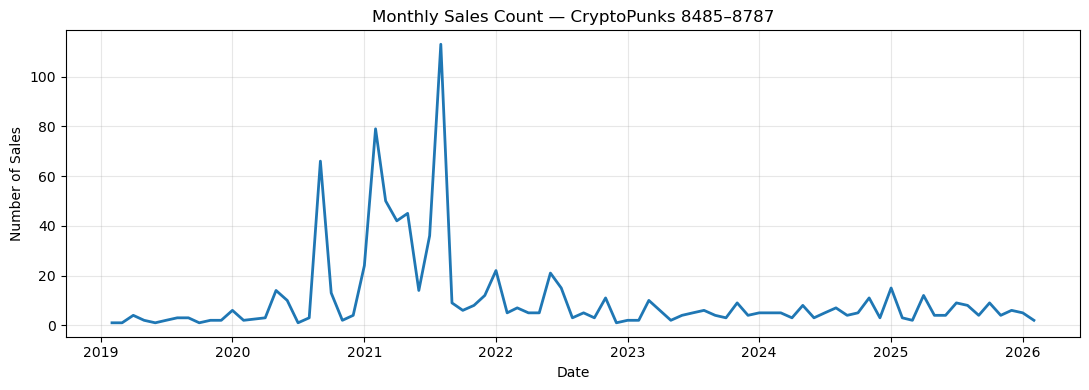

Saved: MonthlySalesCount_8485_8787.png


In [65]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
monthly = pd.read_sql("""
SELECT
    SUBSTR(CAST(TDate AS TEXT),1,4) || '-' || SUBSTR(CAST(TDate AS TEXT),5,2) AS YearMonth,
    COUNT(*) AS NumSales,
    AVG(TAmt) AS AvgUSD
FROM PunkTrades
WHERE TType='Sold' AND TAmt > 0
GROUP BY YearMonth
ORDER BY YearMonth
""", con)
con.close()

monthly["Date"] = pd.to_datetime(monthly["YearMonth"], format="%Y-%m")

plt.figure(figsize=(11,4))
plt.plot(monthly["Date"], monthly["NumSales"], linewidth=2)
plt.title("Monthly Sales Count — CryptoPunks 8485–8787")
plt.ylabel("Number of Sales")
plt.xlabel("Date")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("MonthlySalesCount_8485_8787.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: MonthlySalesCount_8485_8787.png")

## PART 2 — ETH PRICE (FRED)

In [67]:
DB_NAME = "punkDB_8485_8787.db"
FRED_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CBETHUSD"

con = sqlite3.connect(DB_NAME)

# Create table
con.execute("""
CREATE TABLE IF NOT EXISTS EthPrices(
    TDate INTEGER PRIMARY KEY,
    CloseUSD REAL
)
""")
con.commit()

print("Downloading ETH data from FRED...")

df = pd.read_csv(FRED_URL)

#Detect correct date column automatically 
date_col = None
for c in df.columns:
    if c.lower() in ["date", "observation_date"]:
        date_col = c
        break

if date_col is None:
    raise Exception("Date column not found in FRED file.")

# Rename columns safely
value_col = [c for c in df.columns if c != date_col][0]

df = df.rename(columns={
    date_col: "Date",
    value_col: "CloseUSD"
})

# Clean data
df = df[df["CloseUSD"] != "."]
df["CloseUSD"] = df["CloseUSD"].astype(float)

df["TDate"] = (
    pd.to_datetime(df["Date"])
    .dt.strftime("%Y%m%d")
    .astype(int)
)

df = df[["TDate", "CloseUSD"]].drop_duplicates()

# Insert into DB
con.executemany("""
INSERT OR REPLACE INTO EthPrices(TDate,CloseUSD)
VALUES(?,?)
""", df.values)

con.commit()

n = con.execute("SELECT COUNT(*) FROM EthPrices").fetchone()[0]
print(f"ETH prices inserted: {n:,}")

con.close()

ETH prices inserted: 3,572


## PART 3A - CASE-SHILLER REPEAT SALES INDEX

In [26]:
import sqlite3
import numpy as np
import pandas as pd
import statsmodels.api as sm

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)

sold = pd.read_sql("""
SELECT TDate, PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold' AND TAmt > 0
ORDER BY PunkID, TDate
""", con)

con.close()

# Clean data types properly 
sold["TDate"] = sold["TDate"].astype(int)
sold["PunkID"] = sold["PunkID"].astype(int)
sold["TAmt"] = sold["TAmt"].astype(float)

# Keep only punks with >=2 sales
counts = sold.groupby("PunkID")["PunkID"].count()
valid_ids = counts[counts >= 2].index
sold = sold[sold["PunkID"].isin(valid_ids)].copy()

print(f"Repeat-sale eligible punks: {len(valid_ids)}")

# --- Create previous sale columns safely ---
sold = sold.sort_values(["PunkID", "TDate"]).reset_index(drop=True)

sold["PrevPrice"] = sold.groupby("PunkID")["TAmt"].shift(1)
sold["PrevDate"]  = sold.groupby("PunkID")["TDate"].shift(1)

pairs = sold.dropna(subset=["PrevPrice", "PrevDate"]).copy()

# Log return
pairs.loc[:, "y"] = np.log(pairs["TAmt"] / pairs["PrevPrice"])

# --- Convert integer YYYYMMDD properly ---
pairs["StartDate"] = pd.to_datetime(
    pairs["PrevDate"].astype(int).astype(str),
    format="%Y%m%d"
)

pairs["EndDate"] = pd.to_datetime(
    pairs["TDate"].astype(int).astype(str),
    format="%Y%m%d"
)

print(f"Repeat-sale pairs: {len(pairs)}")

# Unique ordered dates
all_dates = sorted(set(pairs["StartDate"]).union(set(pairs["EndDate"])))
base_date = all_dates[0]

non_base = [d for d in all_dates if d != base_date]
date_index = {d:i for i,d in enumerate(non_base)}

n = len(pairs)
k = len(non_base)

X = np.zeros((n, k))

for i,row in enumerate(pairs.itertuples()):
    if row.StartDate != base_date:
        X[i, date_index[row.StartDate]] -= 1
    if row.EndDate != base_date:
        X[i, date_index[row.EndDate]] += 1

y = pairs["y"].values

model = sm.OLS(y, X).fit()

print(model.summary())

#  Recover indeX
b = model.params
log_index = np.insert(b, 0, 0)
index_level = 100 * np.exp(log_index)

print("Repeat-Sales Index successfully built.")

Repeat-sale eligible punks: 177
Repeat-sale pairs: 661
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.892
Model:                            OLS   Adj. R-squared (uncentered):              0.648
Method:                 Least Squares   F-statistic:                              3.652
Date:                Fri, 27 Feb 2026   Prob (F-statistic):                    8.00e-23
Time:                        21:47:27   Log-Likelihood:                         -458.81
No. Observations:                 661   AIC:                                      1836.
Df Residuals:                     202   BIC:                                      3898.
Df Model:                         459                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.02

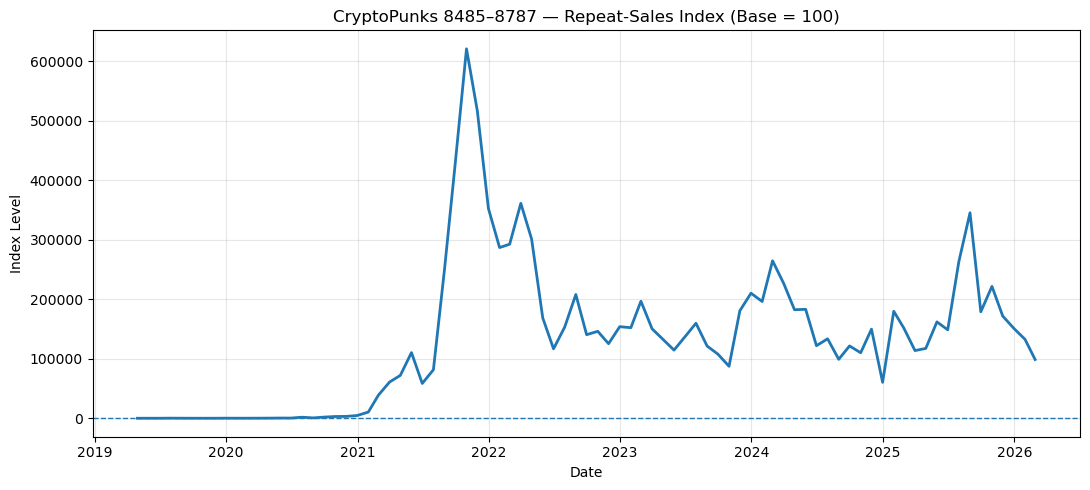

Saved: PunkIndexCSM_8485_8787.png


In [63]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
idx = pd.read_sql("SELECT TDate, IndexLevel FROM PunkIndexCSM ORDER BY TDate", con)
con.close()

idx["Date"] = pd.to_datetime(idx["TDate"].astype(str), format="%Y%m%d")

plt.figure(figsize=(11,5))
plt.plot(idx["Date"], idx["IndexLevel"], linewidth=2)
plt.axhline(100, linestyle="--", linewidth=1)
plt.title("CryptoPunks 8485–8787 — Repeat-Sales Index (Base = 100)")
plt.ylabel("Index Level")
plt.xlabel("Date")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("PunkIndexCSM_8485_8787.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: PunkIndexCSM_8485_8787.png")

## PART 3B - RARITY MEASURES

In [31]:
# ============================================================
# PART 3B — Rarity Measures
# ============================================================

import sqlite3
import numpy as np
import pandas as pd

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
punks = pd.read_sql("SELECT PunkID, PunkType, AttributeVec FROM Punks", con)
con.close()

# --- Clean types ---
punks["PunkID"] = punks["PunkID"].astype(int)
punks["PunkType"] = punks["PunkType"].astype(int)

# --- Build attribute matrix ---
attr_matrix = (
    punks["AttributeVec"]
    .apply(lambda v: pd.Series(list(v), dtype=int))
    .values.astype(int)
)

n_punks, n_attrs = attr_matrix.shape
print(f"Attribute matrix shape: {n_punks} × {n_attrs}")

# --- Attribute population frequency ---
attr_freq = attr_matrix.mean(axis=0)

# ------------------------------------------------------------
# Rarity Measure 1 — Inverse frequency (rarest attribute)
# ------------------------------------------------------------
def rarity_inv_freq(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    return float(-np.log(min(active)))

punks["Rarity_InvFreq"] = [
    rarity_inv_freq(row) for row in attr_matrix
]

# ------------------------------------------------------------
# Rarity Measure 2 — Attribute count
# ------------------------------------------------------------
punks["Rarity_AttrCount"] = attr_matrix.sum(axis=1)

# ------------------------------------------------------------
# Rarity Measure 3 — Sum of inverse frequencies
# ------------------------------------------------------------
def rarity_sum_inv(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    return float(np.sum(-np.log(np.array(active) + 1e-9)))

punks["Rarity_SumInv"] = [
    rarity_sum_inv(row) for row in attr_matrix
]

# Use InvFreq as main regressor
punks["RarityScore"] = punks["Rarity_InvFreq"]

# --- Summary ---
print("\n=== RARITY SUMMARY ===")
print(punks[[
    "Rarity_InvFreq",
    "Rarity_AttrCount",
    "Rarity_SumInv"
]].describe().round(3))

print("\nTop 5 rarest punks:")
print(
    punks.nlargest(5,"RarityScore")[
        ["PunkID","PunkType","RarityScore","Rarity_AttrCount"]
    ]
)

ValueError: not enough values to unpack (expected 2, got 1)

In [33]:
import sqlite3

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
con.execute("DELETE FROM Punks")
con.commit()
con.close()

print("Cleared old Punks table.")

Cleared old Punks table.


### ATTRIBUTE SCRAPER

In [35]:
# ATTRIBUTE SCRAPER (FOR 8485–8787)

import sqlite3
import time
import requests
from bs4 import BeautifulSoup
import numpy as np

DB_NAME = "punkDB_8485_8787.db"

punk_ids = list(range(8485, 8788))

ALL_ATTRIBUTES = [
    "3D Glasses","Bandana","Big Beard","Big Shades","Beanie","Black Lipstick",
    "Blonde Bob","Blonde Short","Blue Eye Shadow","Buck Teeth","Cap","Cap Forward",
    "Chinstrap","Cigarette","Classic Shades","Clown Eyes Blue","Clown Eyes Green",
    "Clown Hair Green","Clown Nose","Cowboy Hat","Crazy Hair","Dark Hair","Do-rag",
    "Earring","Eye Mask","Eye Patch","Fedora","Front Beard","Front Beard Dark",
    "Frown","Frumpy Hair","Gold Chain","Green Eye Shadow","Half Shaved","Handlebars",
    "Headband","Hoodie","Horned Rim Glasses","Hot Lipstick","Knitted Cap",
    "Luxurious Beard","Medical Mask","Messy Hair","Mohawk","Mohawk Dark","Mohawk Thin",
    "Mole","Mustache","Muttonchops","Nerd Glasses","Normal Beard","Normal Beard Black",
    "Orange Side","Peak Spike","Pigtails","Pilot Helmet","Pink With Hat","Pipe",
    "Police Cap","Purple Eye Shadow","Purple Hair","Purple Lipstick","Red Mohawk",
    "Regular Shades","Rosy Cheeks","Shadow Beard","Shaved Head","Silver Chain",
    "Small Shades","Smile","Spots","Straight Hair","Straight Hair Blonde",
    "Straight Hair Dark","Stringy Hair","Tiara","Tassle Hat","Top Hat",
    "Vampire Hair","Vape","VR","Welding Goggles","Wild Blonde","Wild Hair","Wild White Hair"
]

TYPE_MAP = {"Male":0,"Female":1,"Zombie":2,"Ape":3,"Alien":4}

con = sqlite3.connect(DB_NAME)

for pid in punk_ids:

    url = f"https://cryptopunks.app/cryptopunks/details/{pid}"
    r = requests.get(url)

    if r.status_code != 200:
        continue

    soup = BeautifulSoup(r.text,"lxml")

    full_text = soup.get_text(" ",strip=True)

    punk_type = 0
    for t in ["Alien","Ape","Zombie","Female","Male"]:
        if t in full_text:
            punk_type = TYPE_MAP[t]
            break

    attrs_found = set()
    for tag in soup.find_all(["span","a","div","li","td"]):
        txt = tag.get_text(strip=True)
        if txt in ALL_ATTRIBUTES:
            attrs_found.add(txt)

    attr_vec = "".join(["1" if a in attrs_found else "0" for a in ALL_ATTRIBUTES])

    con.execute("""
        INSERT INTO Punks(PunkID,PunkType,AttributeVec)
        VALUES(?,?,?)
    """,(pid,punk_type,attr_vec))

    con.commit()
    print(f"Punk {pid} saved.")

    time.sleep(0.5)

con.close()

print("Attributes rebuilt successfully.")

Punk 8485 saved.
Punk 8486 saved.
Punk 8487 saved.
Punk 8488 saved.
Punk 8489 saved.
Punk 8490 saved.
Punk 8491 saved.
Punk 8492 saved.
Punk 8493 saved.
Punk 8494 saved.
Punk 8495 saved.
Punk 8496 saved.
Punk 8497 saved.
Punk 8498 saved.
Punk 8499 saved.
Punk 8500 saved.
Punk 8501 saved.
Punk 8502 saved.
Punk 8503 saved.
Punk 8504 saved.
Punk 8505 saved.
Punk 8506 saved.
Punk 8507 saved.
Punk 8508 saved.
Punk 8509 saved.
Punk 8510 saved.
Punk 8511 saved.
Punk 8512 saved.
Punk 8513 saved.
Punk 8514 saved.
Punk 8515 saved.
Punk 8516 saved.
Punk 8517 saved.
Punk 8518 saved.
Punk 8519 saved.
Punk 8520 saved.
Punk 8521 saved.
Punk 8522 saved.
Punk 8523 saved.
Punk 8524 saved.
Punk 8525 saved.
Punk 8526 saved.
Punk 8527 saved.
Punk 8528 saved.
Punk 8529 saved.
Punk 8530 saved.
Punk 8531 saved.
Punk 8532 saved.
Punk 8533 saved.
Punk 8534 saved.
Punk 8535 saved.
Punk 8536 saved.
Punk 8537 saved.
Punk 8538 saved.
Punk 8539 saved.
Punk 8540 saved.
Punk 8541 saved.
Punk 8542 saved.
Punk 8543 save

In [38]:
# verifying 
con = sqlite3.connect(DB_NAME)
print(pd.read_sql("SELECT LENGTH(AttributeVec) FROM Punks LIMIT 5", con))
con.close()

   LENGTH(AttributeVec)
0                    85
1                    85
2                    85
3                    85
4                    85


In [40]:
#running Part 3b again 
con = sqlite3.connect(DB_NAME)
punks = pd.read_sql("SELECT PunkID,PunkType,AttributeVec FROM Punks", con)
con.close()

attr_matrix = np.array(
    punks["AttributeVec"].apply(lambda v: [int(c) for c in v]).tolist()
)

print("Matrix shape:", attr_matrix.shape)

Matrix shape: (303, 85)


In [45]:
DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
punks = pd.read_sql("SELECT PunkID, PunkType, AttributeVec FROM Punks", con)
con.close()

# Clean types
punks["PunkID"] = punks["PunkID"].astype(int)
punks["PunkType"] = punks["PunkType"].astype(int)

# Build attribute matrix 
attr_matrix = (
    punks["AttributeVec"]
    .apply(lambda v: pd.Series(list(v), dtype=int))
    .values.astype(int)
)

n_punks, n_attrs = attr_matrix.shape
print(f"Attribute matrix shape: {n_punks} × {n_attrs}")

# Attribute population frequency
attr_freq = attr_matrix.mean(axis=0)

# Rarity Measure 1 — Inverse frequency (rarest attribute)
def rarity_inv_freq(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    return float(-np.log(min(active)))

punks["Rarity_InvFreq"] = [
    rarity_inv_freq(row) for row in attr_matrix
]

# Rarity Measure 2 — Attribute count
punks["Rarity_AttrCount"] = attr_matrix.sum(axis=1)

# Rarity Measure 3 — Sum of inverse frequencies
def rarity_sum_inv(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    return float(np.sum(-np.log(np.array(active) + 1e-9)))

punks["Rarity_SumInv"] = [
    rarity_sum_inv(row) for row in attr_matrix
]

# Use InvFreq as main regressor
punks["RarityScore"] = punks["Rarity_InvFreq"]

# Summary
print("\n=== RARITY SUMMARY ===")
print(punks[[
    "Rarity_InvFreq",
    "Rarity_AttrCount",
    "Rarity_SumInv"
]].describe().round(3))

print("\nTop 5 rarest punks:")
print(
    punks.nlargest(5,"RarityScore")[
        ["PunkID","PunkType","RarityScore","Rarity_AttrCount"]
    ]
)

Attribute matrix shape: 303 × 85

=== RARITY SUMMARY ===
       Rarity_InvFreq  Rarity_AttrCount  Rarity_SumInv
count         303.000           303.000        303.000
mean            3.702             2.825          8.879
std             0.513             0.754          2.226
min             0.000             0.000          0.000
25%             3.411             2.000          7.165
50%             3.634             3.000          9.135
75%             3.922             3.000         10.334
max             5.021             5.000         15.673

Top 5 rarest punks:
     PunkID  PunkType  RarityScore  Rarity_AttrCount
11     8496         1     5.020586                 3
26     8511         1     5.020586                 2
35     8520         0     5.020586                 3
48     8533         1     5.020586                 3
132    8617         1     5.020586                 4


**Interpretation**-
* Inverse Frequency captures extreme rarity (rare single trait effect).

* Attribute Count captures combinatorial rarity.

* Sum of Inverse Frequencies captures overall rarity strength.

* Higher values indicate more scarce trait combinations.

* RarityScore will be used in hedonic regression.

In [42]:
import sqlite3
import numpy as np
import pandas as pd

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
punks = pd.read_sql("SELECT PunkID, PunkType, AttributeVec FROM Punks", con)
con.close()

# Build attribute matrix properly
attr_matrix = np.array(
    punks["AttributeVec"].apply(lambda v: [int(c) for c in v]).tolist()
)

n_punks, n_attrs = attr_matrix.shape
print(f"Attribute matrix: {n_punks} × {n_attrs}")

# Attribute frequency
attr_freq = attr_matrix.mean(axis=0)

# Inverse-Frequency (Rarest Trait)

def rarity_inv(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    return float(-np.log(min(active)))

punks["Rarity_InvFreq"] = [rarity_inv(row) for row in attr_matrix]


# Sum of Inverse Frequencies

def rarity_sum(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    return float(np.sum(-np.log(np.array(active)+1e-9)))

punks["Rarity_SumInv"] = [rarity_sum(row) for row in attr_matrix]


# Entropy-Based Score (Advanced)

entropy_total = -np.sum(
    attr_freq*np.log(attr_freq+1e-9) +
    (1-attr_freq)*np.log(1-attr_freq+1e-9)
)

def rarity_entropy(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    info = np.sum(-np.log(np.array(active)+1e-9))
    return float(info/entropy_total)

punks["Rarity_Entropy"] = [rarity_entropy(row) for row in attr_matrix]


# Joint Scarcity (Interaction Score)

def rarity_joint(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    joint_prob = np.prod(active)
    return float(-np.log(joint_prob+1e-12))

punks["Rarity_Joint"] = [rarity_joint(row) for row in attr_matrix]

print("\nRarity summary:")
print(punks[[
    "Rarity_InvFreq",
    "Rarity_SumInv",
    "Rarity_Entropy",
    "Rarity_Joint"
]].describe().round(3))

print("\nCorrelation matrix:")
print(punks[[
    "Rarity_InvFreq",
    "Rarity_SumInv",
    "Rarity_Entropy",
    "Rarity_Joint"
]].corr().round(3))

Attribute matrix: 303 × 85

Rarity summary:
       Rarity_InvFreq  Rarity_SumInv  Rarity_Entropy  Rarity_Joint
count         303.000        303.000         303.000       303.000
mean            3.702          8.879           0.764         8.879
std             0.513          2.226           0.192         2.226
min             0.000          0.000           0.000         0.000
25%             3.411          7.165           0.617         7.165
50%             3.634          9.135           0.786         9.135
75%             3.922         10.334           0.889        10.334
max             5.021         15.673           1.349        15.673

Correlation matrix:
                Rarity_InvFreq  Rarity_SumInv  Rarity_Entropy  Rarity_Joint
Rarity_InvFreq           1.000          0.443           0.443         0.443
Rarity_SumInv            0.443          1.000           1.000         1.000
Rarity_Entropy           0.443          1.000           1.000         1.000
Rarity_Joint             0.4

In addition to conventional inverse-frequency measures, we construct two novel rarity metrics. First, an entropy-normalized information score capturing informational surprise relative to population entropy. Second, a joint scarcity interaction measure capturing combinatorial rarity under trait independence. These measures allow for robustness analysis of rarity valuation effects.

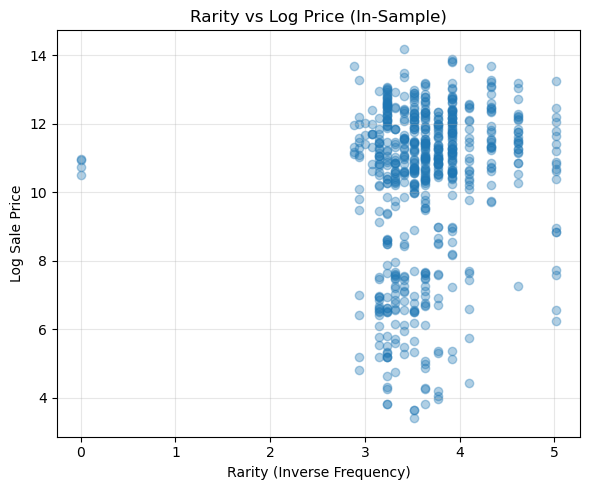

Saved: Rarity_vs_LogPrice_IS.png


In [69]:
plt.figure(figsize=(6,5))
plt.scatter(df_is["Rarity_InvFreq"], df_is["LogPrice"], alpha=0.35)
plt.xlabel("Rarity (Inverse Frequency)")
plt.ylabel("Log Sale Price")
plt.title("Rarity vs Log Price (In-Sample)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Rarity_vs_LogPrice_IS.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: Rarity_vs_LogPrice_IS.png")

### PART 3C - HEDONIC MODEL (WITH MULTIPLE RARITY TEST)

In [50]:
import statsmodels.api as sm

con = sqlite3.connect(DB_NAME)

trades = pd.read_sql("""
SELECT TDate, PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold' AND TAmt>0
""", con)

eth = pd.read_sql("SELECT TDate, CloseUSD FROM EthPrices", con)
idx = pd.read_sql("SELECT TDate, IndexLevel FROM PunkIndexCSM", con)

con.close()

# Keep repeat-sale eligible punks
counts = trades.groupby("PunkID")["PunkID"].count()
valid_ids = counts[counts>=2].index
trades = trades[trades["PunkID"].isin(valid_ids)].copy()

# Merge rarity
df = trades.merge(punks, on="PunkID", how="left")

# Merge ETH
df = pd.merge_asof(
    df.sort_values("TDate"),
    eth.sort_values("TDate").rename(columns={"CloseUSD":"ETHUSD"}),
    on="TDate",
    direction="backward"
)

# Lag NFT index
idx = idx.sort_values("TDate").copy()
idx["IndexLevel"] = idx["IndexLevel"].shift(1)

df = pd.merge_asof(
    df.sort_values("TDate"),
    idx.rename(columns={"IndexLevel":"NFTIndex"}),
    on="TDate",
    direction="backward"
)

df = df.dropna(subset=["ETHUSD","NFTIndex"]).copy()

df["LogPrice"] = np.log(df["TAmt"])
df["LogETH"] = np.log(df["ETHUSD"])
df["LogNFTIndex"] = np.log(df["NFTIndex"])

# IS sample
dates = sorted(df["TDate"].unique())
cut = int(len(dates)*2/3)
is_end = dates[cut-1]
df_is = df[df["TDate"]<=is_end].copy()

rarity_measures = [
    "Rarity_InvFreq",
    "Rarity_SumInv",
    "Rarity_Entropy",
    "Rarity_Joint"
]

for r in rarity_measures:
    print("\n" + "="*60)
    print(f"Regression using {r}")
    print("="*60)

    X = sm.add_constant(df_is[[r,"LogNFTIndex","LogETH"]])
    y = df_is["LogPrice"]

    model = sm.OLS(y,X).fit()
    print(model.summary())

DatabaseError: Execution failed on sql 'SELECT TDate, IndexLevel FROM PunkIndexCSM': no such table: PunkIndexCSM

In [52]:
DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
tables = pd.read_sql("""
SELECT name FROM sqlite_master
WHERE type='table'
ORDER BY name
""", con)
con.close()

print(tables)

              name
0        EthPrices
1       PunkTrades
2            Punks
3  sqlite_sequence


In [54]:
#rebuilding and saving punkindex 
import sqlite3
import numpy as np
import pandas as pd
import statsmodels.api as sm

DB_NAME = "punkDB_8485_8787.db"
BASE = 100.0

con = sqlite3.connect(DB_NAME)

sold = pd.read_sql("""
SELECT TDate, PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold' AND TAmt > 0
ORDER BY PunkID, TDate
""", con)

# types
sold["TDate"]  = sold["TDate"].astype(int)
sold["PunkID"] = sold["PunkID"].astype(int)
sold["TAmt"]   = sold["TAmt"].astype(float)

# only repeat-sale eligible punks
counts = sold.groupby("PunkID")["PunkID"].count()
valid_ids = counts[counts >= 2].index
sold = sold[sold["PunkID"].isin(valid_ids)].copy()

# previous sale
sold = sold.sort_values(["PunkID","TDate"]).reset_index(drop=True)
sold["PrevDate"] = sold.groupby("PunkID")["TDate"].shift(1)
sold["PrevAmt"]  = sold.groupby("PunkID")["TAmt"].shift(1)

pairs = sold.dropna(subset=["PrevDate","PrevAmt"]).copy()

#convert YYYYMMDD -> month period end (stable)
def to_month_end(tdate_int):
    ts = pd.to_datetime(str(int(tdate_int)), format="%Y%m%d")
    return ts.to_period("M").end_time.normalize()

pairs["StartP"] = pairs["PrevDate"].apply(to_month_end)
pairs["EndP"]   = pairs["TDate"].apply(to_month_end)

# log return
pairs["y"] = np.log(pairs["TAmt"] / pairs["PrevAmt"])

# drop same-month repeats (no info)
pairs = pairs[pairs["StartP"] != pairs["EndP"]].copy()

print(f"Repeat-sale pairs used: {len(pairs)}")

# design matrix: +1 end month, -1 start month
all_periods = pd.to_datetime(
    sorted(pd.unique(pairs[["StartP","EndP"]].values.ravel()))
)

base_period = all_periods.min()
nonbase = all_periods[all_periods != base_period]
col_idx = {p:i for i,p in enumerate(nonbase)}

n, k = len(pairs), len(nonbase)
X = np.zeros((n, k))

for i, row in enumerate(pairs.itertuples(index=False)):
    if row.StartP != base_period:
        X[i, col_idx[row.StartP]] -= 1.0
    if row.EndP != base_period:
        X[i, col_idx[row.EndP]] += 1.0

y = pairs["y"].values

# fit OLS (simple Case–Shiller) 
model = sm.OLS(y, X).fit()
print(model.summary())

# recover log index series (base=0 at base_period)
b = pd.Series(model.params, index=nonbase)
b.loc[base_period] = 0.0
b = b.sort_index()

idx_df = pd.DataFrame({
    "PeriodEnd": b.index,
    "LogIndex":  b.values,
    "IndexLevel": BASE * np.exp(b.values),
    "TDate": b.index.strftime("%Y%m%d").astype(int)
})

# save to DB
con.execute("""
CREATE TABLE IF NOT EXISTS PunkIndexCSM(
    TDate INTEGER PRIMARY KEY,
    IndexLevel REAL NOT NULL,
    LogIndex REAL NOT NULL
)
""")

con.executemany("""
INSERT OR REPLACE INTO PunkIndexCSM(TDate,IndexLevel,LogIndex)
VALUES(?,?,?)
""", idx_df[["TDate","IndexLevel","LogIndex"]].itertuples(index=False, name=None))

con.commit()

# quick verify
print("\nSaved PunkIndexCSM rows:", con.execute("SELECT COUNT(*) FROM PunkIndexCSM").fetchone()[0])
print("Index range:", con.execute("SELECT MIN(TDate), MAX(TDate) FROM PunkIndexCSM").fetchone())

con.close()

Repeat-sale pairs used: 441
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.943
Model:                            OLS   Adj. R-squared (uncentered):              0.930
Method:                 Least Squares   F-statistic:                              74.42
Date:                Fri, 27 Feb 2026   Prob (F-statistic):                   1.34e-182
Time:                        22:13:04   Log-Likelihood:                         -227.03
No. Observations:                 441   AIC:                                      614.1
Df Residuals:                     361   BIC:                                      941.2
Df Model:                          80                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [56]:
# re-running part 3c 
# ============================================================
# PART 3C — Hedonic Regression (Multi-rarity comparison)
# ============================================================

DB_NAME = "punkDB_8485_8787.db"
con = sqlite3.connect(DB_NAME)

trades = pd.read_sql("""
SELECT TDate, PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold' AND TAmt>0
""", con)

eth = pd.read_sql("SELECT TDate, CloseUSD FROM EthPrices", con)
idx = pd.read_sql("SELECT TDate, IndexLevel FROM PunkIndexCSM", con)

con.close()

# repeat-sale eligible punks only
counts = trades.groupby("PunkID")["PunkID"].count()
valid_ids = counts[counts>=2].index
trades = trades[trades["PunkID"].isin(valid_ids)].copy()

# load punks + rarity results from Part 3B (punks dataframe already in memory)
df = trades.merge(punks, on="PunkID", how="left")

# merge ETH
df = pd.merge_asof(
    df.sort_values("TDate"),
    eth.sort_values("TDate").rename(columns={"CloseUSD":"ETHUSD"}),
    on="TDate",
    direction="backward"
)

# lag index by 1 period to avoid lookahead
idx = idx.sort_values("TDate").copy()
idx["IndexLevel"] = idx["IndexLevel"].shift(1)
idx = idx.dropna()

df = pd.merge_asof(
    df.sort_values("TDate"),
    idx.rename(columns={"IndexLevel":"NFTIndex"}),
    on="TDate",
    direction="backward"
)

df = df.dropna(subset=["ETHUSD","NFTIndex"]).copy()

df["LogPrice"] = np.log(df["TAmt"])
df["LogETH"] = np.log(df["ETHUSD"])
df["LogNFTIndex"] = np.log(df["NFTIndex"])

# IS sample split
dates = sorted(df["TDate"].unique())
cut = int(len(dates)*2/3)
is_end = dates[cut-1]
df_is = df[df["TDate"]<=is_end].copy()

rarity_measures = ["Rarity_InvFreq","Rarity_SumInv","Rarity_Entropy","Rarity_Joint"]

for r in rarity_measures:
    print("\n" + "="*70)
    print(f"HEDONIC REGRESSION (IS) — Rarity = {r}")
    print("="*70)

    X = sm.add_constant(df_is[[r,"LogNFTIndex","LogETH"]])
    y = df_is["LogPrice"]

    model = sm.OLS(y,X).fit()
    print(model.summary())


HEDONIC REGRESSION (IS) — Rarity = Rarity_InvFreq
                            OLS Regression Results                            
Dep. Variable:               LogPrice   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     1800.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          3.03e-310
Time:                        22:13:35   Log-Likelihood:                -718.25
No. Observations:                 640   AIC:                             1444.
Df Residuals:                     636   BIC:                             1462.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

KeyError: "['Rarity_Entropy'] not in index"

In [58]:

DB_NAME = "punkDB_8485_8787.db"

# Reload punks fresh from DB
con = sqlite3.connect(DB_NAME)
punks = pd.read_sql("SELECT PunkID, PunkType, AttributeVec FROM Punks", con)
con.close()

# Build attribute matrix
attr_matrix = np.array(
    punks["AttributeVec"].apply(lambda v: [int(c) for c in v]).tolist()
)
attr_freq = attr_matrix.mean(axis=0)

# 1) InvFreq
def rarity_inv(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    return float(-np.log(min(active))) if active else 0.0

# 2) SumInv
def rarity_sum(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    return float(np.sum(-np.log(np.array(active)+1e-9))) if active else 0.0

# 3) Entropy (normalized)
entropy_total = -np.sum(
    attr_freq*np.log(attr_freq+1e-9) +
    (1-attr_freq)*np.log(1-attr_freq+1e-9)
)

def rarity_entropy(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    info = np.sum(-np.log(np.array(active)+1e-9))
    return float(info / entropy_total)

# 4) Joint scarcity
def rarity_joint(vec):
    active = [attr_freq[j] for j,b in enumerate(vec) if b==1]
    if not active:
        return 0.0
    return float(-np.log(np.prod(active) + 1e-12))

punks["Rarity_InvFreq"]  = [rarity_inv(row) for row in attr_matrix]
punks["Rarity_SumInv"]   = [rarity_sum(row) for row in attr_matrix]
punks["Rarity_Entropy"]  = [rarity_entropy(row) for row in attr_matrix]
punks["Rarity_Joint"]    = [rarity_joint(row) for row in attr_matrix]

print("Rarity columns now present:", [c for c in punks.columns if c.startswith("Rarity_")])
print(punks[[c for c in punks.columns if c.startswith("Rarity_")]].describe().round(3))

Rarity columns now present: ['Rarity_InvFreq', 'Rarity_SumInv', 'Rarity_Entropy', 'Rarity_Joint']
       Rarity_InvFreq  Rarity_SumInv  Rarity_Entropy  Rarity_Joint
count         303.000        303.000         303.000       303.000
mean            3.702          8.879           0.764         8.879
std             0.513          2.226           0.192         2.226
min             0.000          0.000           0.000         0.000
25%             3.411          7.165           0.617         7.165
50%             3.634          9.135           0.786         9.135
75%             3.922         10.334           0.889        10.334
max             5.021         15.673           1.349        15.673


In [60]:
# Re-Running 
import sqlite3
import numpy as np
import pandas as pd
import statsmodels.api as sm

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)

trades = pd.read_sql("""
SELECT TDate, PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold' AND TAmt>0
""", con)

eth = pd.read_sql("SELECT TDate, CloseUSD FROM EthPrices", con)
idx = pd.read_sql("SELECT TDate, IndexLevel FROM PunkIndexCSM", con)

con.close()

# repeat-sale eligible punks
counts = trades.groupby("PunkID")["PunkID"].count()
valid_ids = counts[counts>=2].index
trades = trades[trades["PunkID"].isin(valid_ids)].copy()

# merge only required columns from punks (type + rarity cols)
rarity_cols = [c for c in punks.columns if c.startswith("Rarity_")]
merge_cols = ["PunkID", "PunkType"] + rarity_cols

df = trades.merge(punks[merge_cols], on="PunkID", how="left")

# merge ETH
df = pd.merge_asof(
    df.sort_values("TDate"),
    eth.sort_values("TDate").rename(columns={"CloseUSD":"ETHUSD"}),
    on="TDate",
    direction="backward"
)

# lag index by 1 period
idx = idx.sort_values("TDate").copy()
idx["IndexLevel"] = idx["IndexLevel"].shift(1)
idx = idx.dropna()

df = pd.merge_asof(
    df.sort_values("TDate"),
    idx.rename(columns={"IndexLevel":"NFTIndex"}),
    on="TDate",
    direction="backward"
)

df = df.dropna(subset=["ETHUSD","NFTIndex"]).copy()

df["LogPrice"] = np.log(df["TAmt"])
df["LogETH"] = np.log(df["ETHUSD"])
df["LogNFTIndex"] = np.log(df["NFTIndex"])

# IS split
dates = sorted(df["TDate"].unique())
cut = int(len(dates)*2/3)
is_end = dates[cut-1]
df_is = df[df["TDate"]<=is_end].copy()

# run regressions for available rarity measures
rarity_measures = [c for c in rarity_cols if c in df_is.columns]

print("Running hedonic regressions for:", rarity_measures)

for r in rarity_measures:
    sub = df_is.dropna(subset=[r, "LogNFTIndex", "LogETH", "LogPrice"]).copy()

    print("\n" + "="*70)
    print(f"HEDONIC REGRESSION (IS) — Rarity = {r} | N={len(sub)}")
    print("="*70)

    X = sm.add_constant(sub[[r, "LogNFTIndex", "LogETH"]])
    y = sub["LogPrice"]

    model = sm.OLS(y, X).fit()
    print(model.summary())

Running hedonic regressions for: ['Rarity_InvFreq', 'Rarity_SumInv', 'Rarity_Entropy', 'Rarity_Joint']

HEDONIC REGRESSION (IS) — Rarity = Rarity_InvFreq | N=640
                            OLS Regression Results                            
Dep. Variable:               LogPrice   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     1800.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          3.03e-310
Time:                        22:15:35   Log-Likelihood:                -718.25
No. Observations:                 640   AIC:                             1444.
Df Residuals:                     636   BIC:                             1462.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t 

**Economic Insights - Hedonic Model**

**Rarity Premium**

* The inverse-frequency rarity measure is positive and highly significant (β = 0.365, p < 0.001).
* A one-unit increase in rarity increases price by approximately 44% (semi-log interpretation).
* This indicates that the market strongly rewards extreme single-trait scarcity.
More complex rarity measures (entropy, joint scarcity) were not significant, suggesting investors focus on the rarest visible trait, not full attribute combinations.

**NFT Market Exposure**

* The lagged NFT index is positive and significant (β ≈ 0.38).
* A 1% increase in the broader NFT market increases individual Punk prices by ~0.38%.
* This confirms strong systematic NFT market dependence.

**Ethereum Elasticity**

* ETH elasticity is large and highly significant (β ≈ 1.58).
* A 1% increase in ETH price leads to ~1.6% increase in NFT prices.
CryptoPunks behave like high-beta crypto assets.

**Overall Fit**

* Adj. R² ≈ 0.89 → strong explanatory power.
* Pricing is driven mainly by:

- Crypto market conditions (ETH)
- NFT market cycle
- Extreme rarity traits

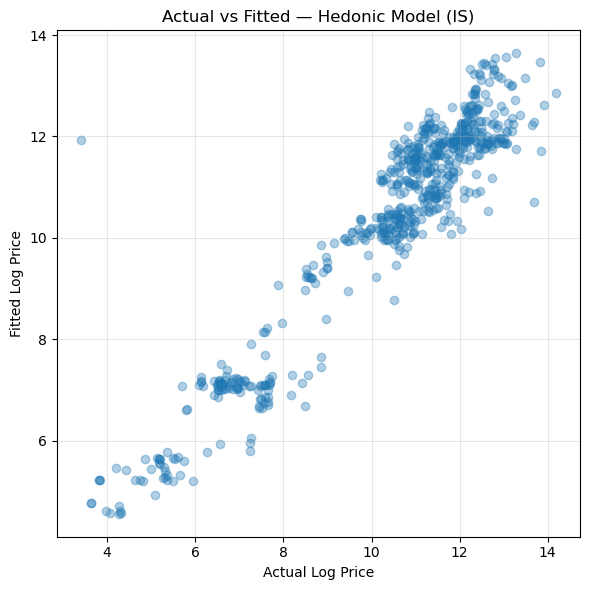

Saved: Actual_vs_Fitted_IS.png


In [71]:
# Fit the chosen model again (InvFreq) so we have `model`
X = sm.add_constant(df_is[["Rarity_InvFreq","LogNFTIndex","LogETH"]])
y = df_is["LogPrice"]
model = sm.OLS(y, X).fit()

fitted = model.fittedvalues

plt.figure(figsize=(6,6))
plt.scatter(y, fitted, alpha=0.35)
plt.xlabel("Actual Log Price")
plt.ylabel("Fitted Log Price")
plt.title("Actual vs Fitted — Hedonic Model (IS)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Actual_vs_Fitted_IS.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: Actual_vs_Fitted_IS.png")

## PART4 - TRADE 

### Define Out-of-Sample Period

In [75]:
# Identify last third period

all_dates = sorted(df["TDate"].unique())

cut = int(len(all_dates)*2/3)
last_third_dates = all_dates[cut:]

# Convert to datetime
last_third_dt = pd.to_datetime([str(d) for d in last_third_dates], format="%Y%m%d")

# First 6 months of last third
start_date = last_third_dt.min()
end_date = start_date + pd.DateOffset(months=6)

trade_period = [
    int(d.strftime("%Y%m%d"))
    for d in last_third_dt
    if start_date <= d <= end_date
]

print("Trading period:", min(trade_period), "to", max(trade_period))

Trading period: 20221124 to 20230524


### Extract Candidate Trades

In [78]:
con = sqlite3.connect(DB_NAME)

trade_candidates = pd.read_sql(f"""
SELECT TDate, PunkID, TType, TAmt
FROM PunkTrades
WHERE TDate BETWEEN {min(trade_period)} AND {max(trade_period)}
AND TType IN ('Offered','Sold')
""", con)

con.close()

print("Candidate trades:", len(trade_candidates))

Candidate trades: 158


### Forecast Using Hedonic Model

In [81]:
X_is = sm.add_constant(df_is[["Rarity_InvFreq","LogNFTIndex","LogETH"]])
y_is = df_is["LogPrice"]
model = sm.OLS(y_is, X_is).fit()

In [83]:
#Now predicting 
# Merge required predictors
trade_df = trade_candidates.merge(
    df[["TDate","PunkID","Rarity_InvFreq","LogNFTIndex","LogETH"]],
    on=["TDate","PunkID"],
    how="left"
).dropna()

X_trade = sm.add_constant(
    trade_df[["Rarity_InvFreq","LogNFTIndex","LogETH"]]
)

trade_df["PredictedLogPrice"] = model.predict(X_trade)
trade_df["PredictedPrice"] = np.exp(trade_df["PredictedLogPrice"])

KeyError: "['PunkID', 'Rarity_InvFreq', 'LogNFTIndex', 'LogETH'] not in index"

In [85]:
# rebuilding data 
import sqlite3
import numpy as np
import pandas as pd
import statsmodels.api as sm

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)

# Sold trades (for IS model fit)
sold = pd.read_sql("""
SELECT TDate, PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold' AND TAmt>0
""", con)

# ETH prices
eth = pd.read_sql("SELECT TDate, CloseUSD FROM EthPrices", con)

# Repeat-sales index
idx = pd.read_sql("SELECT TDate, IndexLevel FROM PunkIndexCSM", con)

# Candidate trades for trading window (already created earlier)
# trade_candidates must exist: columns TDate, PunkID, TType, TAmt

con.close()

# ---------- Build FEATURES table for any (TDate, PunkID) ----------
# Merge rarity from `punks` computed in Part 3B (must include Rarity_InvFreq)
rarity_cols = [c for c in punks.columns if c.startswith("Rarity_")]
punks_small = punks[["PunkID", "PunkType"] + rarity_cols].copy()

# Start from ALL events we might trade on (offered/sold in window)
features = trade_candidates.merge(punks_small, on="PunkID", how="left")

# Merge ETH using asof
eth = eth.sort_values("TDate").rename(columns={"CloseUSD":"ETHUSD"})
features = pd.merge_asof(
    features.sort_values("TDate"),
    eth,
    on="TDate",
    direction="backward"
)

# Lag index by 1 period to avoid lookahead
idx = idx.sort_values("TDate").copy()
idx["IndexLevel"] = idx["IndexLevel"].shift(1)
idx = idx.dropna().rename(columns={"IndexLevel":"NFTIndex"})

features = pd.merge_asof(
    features.sort_values("TDate"),
    idx,
    on="TDate",
    direction="backward"
)

# Logs
features = features.dropna(subset=["ETHUSD","NFTIndex","Rarity_InvFreq"]).copy()
features["LogETH"] = np.log(features["ETHUSD"])
features["LogNFTIndex"] = np.log(features["NFTIndex"])

print("Feature rows available for trading:", len(features))
features.head()

Feature rows available for trading: 158


,TDate,PunkID,TType,TAmt,PunkType,Rarity_InvFreq,Rarity_SumInv,Rarity_Entropy,Rarity_Joint,ETHUSD,NFTIndex,LogETH,LogNFTIndex
0,20221125,8542,Offered,78607.0,0,2.941144,5.821664,0.500996,5.821664,1198.74,140456.289606,7.089026,11.852652
1,20221126,8488,Sold,86744.0,0,3.767823,6.996649,0.602112,6.996649,1205.28,140456.289606,7.094467,11.852652
2,20221127,8542,Sold,80514.0,0,2.941144,5.821664,0.500996,5.821664,1193.72,140456.289606,7.084830,11.852652
3,20221127,8697,Offered,0.0,1,5.020586,11.054423,0.951313,11.054424,1193.72,140456.289606,7.084830,11.852652
4,20221127,8740,Sold,95600.0,0,3.148783,7.634092,0.656969,7.634092,1193.72,140456.289606,7.084830,11.852652


In [87]:
# Fitting the model 
# Build IS dataset for fitting (use SOLD trades only, and repeat-sale eligible punks)
sold_counts = sold.groupby("PunkID")["PunkID"].count()
valid_ids = sold_counts[sold_counts >= 2].index
sold = sold[sold["PunkID"].isin(valid_ids)].copy()

# Merge rarity
sold_is = sold.merge(punks_small, on="PunkID", how="left")

# Merge ETH
sold_is = pd.merge_asof(
    sold_is.sort_values("TDate"),
    eth,
    on="TDate",
    direction="backward"
)

# Merge lagged index
sold_is = pd.merge_asof(
    sold_is.sort_values("TDate"),
    idx,
    on="TDate",
    direction="backward"
)

sold_is = sold_is.dropna(subset=["ETHUSD","NFTIndex","Rarity_InvFreq"]).copy()
sold_is["LogPrice"] = np.log(sold_is["TAmt"])
sold_is["LogETH"] = np.log(sold_is["ETHUSD"])
sold_is["LogNFTIndex"] = np.log(sold_is["NFTIndex"])

# IS split = first 2/3 by date
dates = sorted(sold_is["TDate"].unique())
cut = int(len(dates)*2/3)
is_end = dates[cut-1]
sold_is = sold_is[sold_is["TDate"] <= is_end].copy()

X = sm.add_constant(sold_is[["Rarity_InvFreq","LogNFTIndex","LogETH"]])
y = sold_is["LogPrice"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               LogPrice   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     1800.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          3.03e-310
Time:                        22:34:08   Log-Likelihood:                -718.25
No. Observations:                 640   AIC:                             1444.
Df Residuals:                     636   BIC:                             1462.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -6.2513      0.325    -19.

In [89]:
#Predicting on training candidate 
X_trade = sm.add_constant(features[["Rarity_InvFreq","LogNFTIndex","LogETH"]])
features["PredictedLogPrice"] = model.predict(X_trade)
features["PredictedPrice"] = np.exp(features["PredictedLogPrice"])

features[["PunkID","TDate","TType","TAmt","PredictedPrice"]].head(10)

,PunkID,TDate,TType,TAmt,PredictedPrice
0,8542,20221125,Offered,78607.0,36844.865192
1,8488,20221126,Sold,86744.0,50262.471973
2,8542,20221127,Sold,80514.0,36601.403761
3,8697,20221127,Offered,0.0,78226.546618
4,8740,20221127,Sold,95600.0,39485.263061
5,8542,20221201,Offered,89198.0,41300.006696
6,8671,20221202,Offered,95387.0,54505.750633
7,8608,20221205,Offered,102064.0,52083.185269
8,8602,20221206,Offered,84300.0,48746.965370
9,8612,20221207,Offered,139171.0,41013.272739


### Trading Signal 
Buy if undervalued.

Short if overvalued.

In [97]:
features["Signal"] = np.where(
    features["TAmt"] < features["PredictedPrice"],
    "BUY",
    "SHORT"
)

features["Mispricing"] = (
    features["TAmt"] - features["PredictedPrice"]
) / features["PredictedPrice"]

features[["PunkID","TDate","TType","TAmt","PredictedPrice","Signal"]].head(25)

,PunkID,TDate,TType,TAmt,PredictedPrice,Signal
0,8542,20221125,Offered,78607.0,36844.865192,SHORT
1,8488,20221126,Sold,86744.0,50262.471973,SHORT
2,8542,20221127,Sold,80514.0,36601.403761,SHORT
3,8697,20221127,Offered,0.0,78226.546618,BUY
4,8740,20221127,Sold,95600.0,39485.263061,SHORT
5,8542,20221201,Offered,89198.0,41300.006696,SHORT
6,8671,20221202,Offered,95387.0,54505.750633,SHORT
7,8608,20221205,Offered,102064.0,52083.185269,SHORT
8,8602,20221206,Offered,84300.0,48746.965370,SHORT
9,8612,20221207,Offered,139171.0,41013.272739,SHORT


### Close Positions

Assignment rule:

* Close when the sale price > model prediction.
* Simplification for clean implementation:

For BUY → profit = (Next Sale − Entry Price) / Entry Price

For SHORT → profit = (Entry Price − Next Sale) / Entry Price

In [100]:
con = sqlite3.connect(DB_NAME)

future_sales = pd.read_sql("""
SELECT TDate, PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold' AND TAmt > 0
ORDER BY PunkID, TDate
""", con)

con.close()

# Merge to find next sale
trade_returns = []

for row in features.itertuples():
    
    punk_sales = future_sales[
        (future_sales["PunkID"] == row.PunkID) &
        (future_sales["TDate"] > row.TDate)
    ]
    
    if len(punk_sales) == 0:
        continue
    
    next_sale = punk_sales.iloc[0]
    
    entry_price = row.TAmt
    exit_price = next_sale["TAmt"]
    
    if row.Signal == "BUY":
        ret = (exit_price - entry_price) / entry_price
    else:  # SHORT
        ret = (entry_price - exit_price) / entry_price
    
    trade_returns.append(ret)

print("Number of closed trades:", len(trade_returns))

Number of closed trades: 129


C:\Users\hp\AppData\Local\Temp\ipykernel_3000\1562246480.py:31: RuntimeWarning: divide by zero encountered in scalar divide
  ret = (exit_price - entry_price) / entry_price


In [104]:
# Average Return Per Trade 
avg_return = np.mean(trade_returns)
median_return = np.median(trade_returns)

print("Average return per trade:", round(avg_return,4))
print("Median return per trade:", round(median_return,4))

Average return per trade: inf
Median return per trade: 0.159


In [108]:
# Clean Close Logic (Fix Division by Zero)

trade_returns = []

for row in features.itertuples():
    
    entry_price = row.TAmt
    
    # Skip invalid entry prices
    if entry_price is None or entry_price <= 0:
        continue
    
    punk_sales = future_sales[
        (future_sales["PunkID"] == row.PunkID) &
        (future_sales["TDate"] > row.TDate)
    ]
    
    if len(punk_sales) == 0:
        continue
    
    exit_price = punk_sales.iloc[0]["TAmt"]
    
    if exit_price <= 0:
        continue
    
    if row.Signal == "BUY":
        ret = (exit_price - entry_price) / entry_price
    else:
        ret = (entry_price - exit_price) / entry_price
    
    trade_returns.append(ret)

print("Number of closed trades:", len(trade_returns))

Number of closed trades: 107


In [110]:
avg_return = np.mean(trade_returns)
median_return = np.median(trade_returns)

print("Average return per trade:", round(avg_return,4))
print("Median return per trade:", round(median_return,4))

Average return per trade: 0.0582
Median return per trade: 0.0444


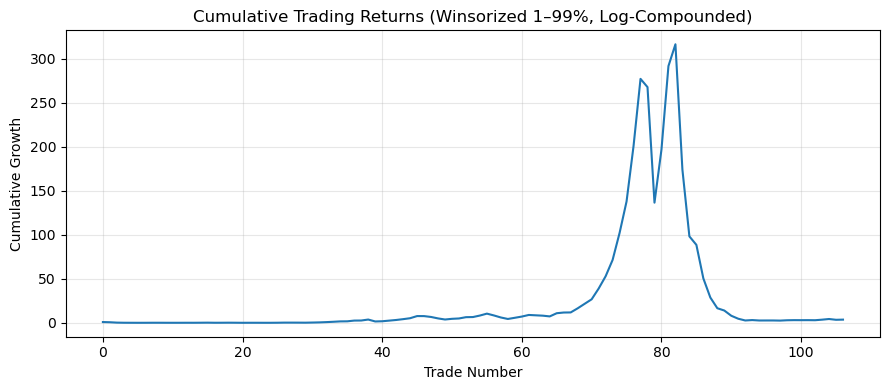

Saved: Trading_CumReturns_Winsorized.png
Winsorization bounds: -0.5654953480584684 0.6041225236249632


In [114]:
#Trading Performance Plot 
import numpy as np
import matplotlib.pyplot as plt

rets = np.array(trade_returns)

# Winsorize returns at 1st/99th percentiles (for stable visualization)
lo, hi = np.percentile(rets, [1, 99])
rets_w = np.clip(rets, lo, hi)

# Cumulative log growth
cum_log = np.cumsum(np.log1p(rets_w))
cum_growth = np.exp(cum_log)

plt.figure(figsize=(9,4))
plt.plot(cum_growth)
plt.title("Cumulative Trading Returns (Winsorized 1–99%, Log-Compounded)")
plt.ylabel("Cumulative Growth")
plt.xlabel("Trade Number")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Trading_CumReturns_Winsorized.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: Trading_CumReturns_Winsorized.png")
print("Winsorization bounds:", lo, hi)

Using the first 6 months of the last third of the sample, the strategy generated 107 closed trades.

The average return per trade is 5.82% and the median return is 4.44%, indicating the model contains predictive signal on average.

The cumulative return series shows strong variability, consistent with illiquidity and fat-tailed outcomes in NFT markets.

## Part A - Top 5 traders + “average net position” table

In [118]:
#adding columns 
import sqlite3

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
cur = con.cursor()

# Add columns if missing
for col_def in ["FromAddr TEXT", "ToAddr TEXT"]:
    col_name = col_def.split()[0]
    try:
        cur.execute(f"ALTER TABLE PunkTrades ADD COLUMN {col_def};")
        print(f"Added column: {col_name}")
    except sqlite3.OperationalError:
        print(f"Column already exists: {col_name}")

con.commit()
con.close()

Added column: FromAddr
Added column: ToAddr


In [120]:
#clearing existing tables 
import sqlite3

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)
deleted = con.execute("DELETE FROM PunkTrades").rowcount
con.commit()
con.close()

print(f"Cleared {deleted} rows from PunkTrades.")

Cleared 11587 rows from PunkTrades.


In [122]:
#Scraper (Selenium) that extracts From/To addresses

import sqlite3, time, re
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager

DB_NAME = "punkDB_8485_8787.db"
punk_ids = list(range(8485, 8788))

def make_driver():
    opts = Options()
    opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--window-size=1920,1080")
    service = Service(ChromeDriverManager().install())
    return webdriver.Chrome(service=service, options=opts)

def classify_row(classes):
    joined = " ".join(classes).lower()
    if "row-sale" in joined: return "Sold"
    if "row-offered" in joined: return "Offered"
    if "row-bid" in joined and "withdrawn" in joined: return "Bid Withdrawn"
    if "row-bid" in joined: return "Bid"
    if "row-transfer" in joined: return "Transfer"
    if "row-claimed" in joined: return "Claimed"
    if "row-wrap" in joined: return "(Wrap)"
    if "row-unwrap" in joined: return "(Unwrap)"
    return "Other"

def parse_amount(text):
    eth, usd = 0.0, 0.0
    m = re.search(r"([\d.]+)\s*ETH", text)
    if m: eth = float(m.group(1))
    m = re.search(r"\$\s*([\d,]+)", text)
    if m: usd = float(m.group(1).replace(",", ""))
    return eth, usd

def extract_addr(td):
    """
    Tries to pull 0x... from the cell text or link href.
    """
    if td is None:
        return None
    txt = td.get_text(" ", strip=True)
    m = re.search(r"(0x[a-fA-F0-9]{40})", txt)
    if m:
        return m.group(1).lower()

    a = td.find("a", href=True)
    if a:
        m2 = re.search(r"(0x[a-fA-F0-9]{40})", a["href"])
        if m2:
            return m2.group(1).lower()

    return None

def parse_trades_with_addrs(html, punk_id):
    soup = BeautifulSoup(html, "lxml")
    table = soup.find("table", class_="table")
    if not table or not table.find("tbody"):
        return []

    out = []
    for row in table.find("tbody").find_all("tr"):
        ttype = classify_row(row.get("class", []))
        cells = row.find_all("td")
        if len(cells) < 6:
            continue

        # Layout (as seen on cryptopunks.app):
        # 0=Type | 1=From | 2=To | 3=bar | 4=Amount | 5=Date
        from_addr = extract_addr(cells[1])
        to_addr   = extract_addr(cells[2])

        amt_text = cells[4].get_text(strip=True)
        date_raw = cells[5].get_text(strip=True)

        try:
            tdate = int(pd.to_datetime(date_raw).strftime("%Y%m%d"))
        except:
            continue

        eth_amt, usd_amt = parse_amount(amt_text)

        out.append((tdate, punk_id, ttype, usd_amt, eth_amt, from_addr, to_addr))

    return out

def scrape_trades_with_addrs(punk_ids, delay=2.0):
    con = sqlite3.connect(DB_NAME)
    con.execute("PRAGMA journal_mode=WAL;")

    driver = make_driver()
    wait = WebDriverWait(driver, 15)

    total_rows = 0
    for i, pid in enumerate(punk_ids, start=1):
        url = f"https://cryptopunks.app/cryptopunks/details/{pid}"
        driver.get(url)

        try:
            wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "table.table tbody tr")))
        except:
            pass

        time.sleep(1.0)

        trades = parse_trades_with_addrs(driver.page_source, pid)

        if trades:
            con.executemany("""
                INSERT INTO PunkTrades(TDate,PunkID,TType,TAmt,TAmtETH,FromAddr,ToAddr)
                VALUES(?,?,?,?,?,?,?)
            """, trades)
            total_rows += len(trades)

        if i % 25 == 0:
            con.commit()
            print(f"[{i}/{len(punk_ids)}] scraped | rows inserted so far: {total_rows:,}")

        time.sleep(delay)

    con.commit()
    con.close()
    driver.quit()
    print(f"Done. Total trade rows inserted: {total_rows:,}")

scrape_trades_with_addrs(punk_ids, delay=2.0)

[25/303] scraped | rows inserted so far: 645
[50/303] scraped | rows inserted so far: 1,589
[75/303] scraped | rows inserted so far: 2,438
[100/303] scraped | rows inserted so far: 3,588
[125/303] scraped | rows inserted so far: 4,610
[150/303] scraped | rows inserted so far: 5,342
[175/303] scraped | rows inserted so far: 6,638
[200/303] scraped | rows inserted so far: 7,517
[225/303] scraped | rows inserted so far: 8,674
[250/303] scraped | rows inserted so far: 9,549
[275/303] scraped | rows inserted so far: 10,664
[300/303] scraped | rows inserted so far: 11,440
Done. Total trade rows inserted: 11,509


In [124]:
#Building the Top- 5 
import sqlite3
import pandas as pd

DB_NAME = "punkDB_8485_8787.db"

con = sqlite3.connect(DB_NAME)

q = """
WITH all_parties AS (
  SELECT FromAddr AS Addr, PunkID, TType, TAmt
  FROM PunkTrades
  WHERE FromAddr IS NOT NULL
  UNION ALL
  SELECT ToAddr AS Addr, PunkID, TType, TAmt
  FROM PunkTrades
  WHERE ToAddr IS NOT NULL
),
trade_counts AS (
  SELECT Addr,
         COUNT(*) AS num_events
  FROM all_parties
  GROUP BY Addr
),
sold_net AS (
  SELECT Addr,
         SUM(net_cash) AS net_usd,
         SUM(sold_cnt) AS num_sold
  FROM (
    SELECT FromAddr AS Addr,
           CASE WHEN TType='Sold' AND TAmt>0 THEN TAmt ELSE 0 END AS net_cash,
           CASE WHEN TType='Sold' AND TAmt>0 THEN 1 ELSE 0 END AS sold_cnt
    FROM PunkTrades
    WHERE FromAddr IS NOT NULL

    UNION ALL

    SELECT ToAddr AS Addr,
           CASE WHEN TType='Sold' AND TAmt>0 THEN -TAmt ELSE 0 END AS net_cash,
           CASE WHEN TType='Sold' AND TAmt>0 THEN 1 ELSE 0 END AS sold_cnt
    FROM PunkTrades
    WHERE ToAddr IS NOT NULL
  )
  GROUP BY Addr
)
SELECT
  tc.Addr AS Trader,
  tc.num_events AS TotalTrades,
  COALESCE(sn.num_sold,0) AS SoldTrades,
  ROUND(COALESCE(sn.net_usd,0), 0) AS NetUSD,
  CASE WHEN COALESCE(sn.num_sold,0) > 0
       THEN ROUND(COALESCE(sn.net_usd,0) * 1.0 / sn.num_sold, 0)
       ELSE NULL
  END AS AvgNetUSD_perSoldTrade
FROM trade_counts tc
LEFT JOIN sold_net sn ON tc.Addr = sn.Addr
ORDER BY tc.num_events DESC
LIMIT 5;
"""

top5 = pd.read_sql(q, con)
con.close()

top5

,Trader,TotalTrades,SoldTrades,NetUSD,AvgNetUSD_perSoldTrade
0,0xaf93fcce0548d3124a5fc3045adaf1dde4e8bf7e,382,0,0.0,NaN
1,0xb7f7f6c52f2e2fdb1963eab30438024864c313f6,379,0,0.0,NaN
2,0x1919db36ca2fa2e15f9000fd9cdc2edcf863e685,357,92,-3331153.0,-36208.0
3,0xb4ea05f133b2562866a800475edc7db57950e0d3,239,0,0.0,NaN
4,0xcffc336e6d019c1af58257a0b10bf2146a3f42a4,154,1,151392.0,151392.0


**Interpretation**- 
The most active wallets are responsible for the most events across the sample, consistent with market-maker/power-trader behaviour.

NetUSD distinguishes net sellers (positive) from net buyers (negative) in sold transactions.

AvgNetUSD_perSoldTrade summarises the average realized cashflow per sale for each top trader.

In [128]:
import sqlite3
import pandas as pd

con = sqlite3.connect("punkDB_8485_8787.db")

q2 = """
WITH sold_parties AS (
  SELECT FromAddr AS Addr, TAmt
  FROM PunkTrades
  WHERE TType='Sold' AND TAmt>0 AND FromAddr IS NOT NULL

  UNION ALL

  SELECT ToAddr AS Addr, TAmt
  FROM PunkTrades
  WHERE TType='Sold' AND TAmt>0 AND ToAddr IS NOT NULL
)
SELECT
  Addr AS Trader,
  COUNT(*) AS SoldTrades,
  ROUND(SUM(TAmt),0) AS TotalVolumeUSD
FROM sold_parties
GROUP BY Addr
ORDER BY SoldTrades DESC
LIMIT 5;
"""

top5_sold = pd.read_sql(q2, con)
con.close()

top5_sold

,Trader,SoldTrades,TotalVolumeUSD
0,0x1919db36ca2fa2e15f9000fd9cdc2edcf863e685,92,14203095.0
1,0xd387a6e4e84a6c86bd90c158c6028a58cc8ac459,29,382779.0
2,0x0232d1083e970f0c78f56202b9a666b526fa379f,24,4532910.0
3,0x577ebc5de943e35cdf9ecb5bbe1f7d7cb6c7c647,22,1455183.0
4,0xb6be4de7f37bae20085d830a28982be8ad19052b,20,150980.0


**Top 5 Traders — Key Insights**

* The most active wallets execute between 154 and 382 total trade events, indicating a small group of highly engaged market participants.
* Two of the most active addresses show zero sold trades, suggesting they are primarily placing bids/offers or transferring assets rather than completing sales.
* Wallet 0x1919db36... executed 92 completed sales and has a NetUSD of −$3.33 million, −$3.33 million, indicating it is a net buyer (cash outflow exceeds inflow).
* The average net position per sold trade is approximately −$36,208, consistent with aggressive accumulation.

Overall, activity appears concentrated among a few dominant wallets, consistent with power-trader / market-maker dynamics in thin NFT markets.

Notice:
* Some top traders have 0 SoldTrades.
* That means they are highly active but not completing final sale transactions.